# Fake Job Posting Detection Using Explainable NLP Models

**Name: Heng Xin Phei**

**Matric No.: 23005228**

---




## Notebook Content (Data Science Life Cycle)
1) Business Understanding
2) Data Understanding
3) Data Preparation + Feature Engineering
4) Exploratory Data Analysis (EDA)  
5) Encoding
6) Modelling
7) Model Evaluation
8) Feature Importance Analysis
9) Explainable AI (XAI)  
5) Deployment


**Dataset**: Kaggle ["Real or Fake Job Posting Prediction" ](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction)

**Target**: `fraudulent` (0 = real, 1 = fake)

# **Business Understanding**

Goal:
- Detect whether a job posting is real (0) or fraudulent (1).

Objectives:
1) Develop classification models to detect real vs fake job postings.
2) Evaluate models using accuracy, precision, recall, F1-score (and PR-AUC).
3) Compare traditional NLP (TF-IDF) vs modern embeddings (Word2Vec, DistilBERT).
4) Deploy an explainable system (LIME) highlighting key text features affecting decisions.

Gap: explainability + systematic comparison + treat class imbalance.

# **Data Understanding**

## 2. Data Understanding

### Environment Setup

In [1]:
import sys, site
print("Python exe:", sys.executable)
print("Python version:", sys.version)
print("User site:", site.getusersitepackages())


Python exe: C:\Users\xinph\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe
Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
User site: C:\Users\xinph\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages


In [1]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)


2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import os

PROJECT_DIR = "."

DATA_DIR   = os.path.join(PROJECT_DIR, "data")
# before preprocessing
EDA_BEFORE_DIR = os.path.join(PROJECT_DIR, "eda_before")
# after preprocessing
EDA_AFTER_DIR = os.path.join(PROJECT_DIR, "eda_after")   
EVAL_DIR   = os.path.join(PROJECT_DIR, "artifacts_eval")
DEPLOY_DIR = os.path.join(PROJECT_DIR, "artifacts_deploy")
FEAT_DIR = os.path.join(PROJECT_DIR, "feature_importance_outputs")
XAI_DIR = os.path.join(PROJECT_DIR, "xai_outputs")
DEMO_DIR   = os.path.join(PROJECT_DIR, "dataset_examples")

for d in [DATA_DIR, EDA_BEFORE_DIR, EDA_AFTER_DIR, EVAL_DIR, DEPLOY_DIR, FEAT_DIR, XAI_DIR, DEMO_DIR]:
    os.makedirs(d, exist_ok=True)

CSV_PATH   = os.path.join(DATA_DIR, "fake_job_postings.csv")
CLEAN_PATH = os.path.join(DATA_DIR, "fake_job_postings_cleaned.csv")

print("PROJECT_DIR:", PROJECT_DIR)
print("CSV_PATH:", CSV_PATH)
print("CLEAN_PATH:", CLEAN_PATH)
print("EDA_BEFORE_DIR:", EDA_BEFORE_DIR)
print("EDA_AFTER_DIR:", EDA_AFTER_DIR)
print("EVAL_DIR:", EVAL_DIR)
print("DEPLOY_DIR:", DEPLOY_DIR)
print("XAI_DIR:", XAI_DIR)
print("FEAT_DIR:", FEAT_DIR)
print("DEMO_DIR:", DEMO_DIR)

PROJECT_DIR: .
CSV_PATH: .\data\fake_job_postings.csv
CLEAN_PATH: .\data\fake_job_postings_cleaned.csv
EDA_BEFORE_DIR: .\eda_before
EDA_AFTER_DIR: .\eda_after
EVAL_DIR: .\artifacts_eval
DEPLOY_DIR: .\artifacts_deploy
XAI_DIR: .\xai_outputs
FEAT_DIR: .\feature_importance_outputs
DEMO_DIR: .\dataset_examples


### Install & import libraries

In [ ]:
%pip -q install contractions bs4 lime gensim xgboost transformers datasets accelerate sentencepiece shap streamlit pyngrok wordcloud

import os, re, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random


from bs4 import BeautifulSoup
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter

from wordcloud import WordCloud
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier


from xgboost import XGBClassifier
import xgboost as xgb_lib
import xgboost
from scipy.sparse import hstack, csr_matrix

from gensim.models import Word2Vec

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from transformers import set_seed
from lime.lime_text import LimeTextExplainer

Note: you may need to restart the kernel to use updated packages.


In [4]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Load dataset + audit

In [15]:
# load dataset
df = pd.read_csv(CSV_PATH)

# preview dataset
print("Shape:", df.shape)
display(df.head(3))
print("\nColumns:", df.columns.tolist())

Shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0



Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [5]:
# audit check
def audit_table(dataframe):
    audit = pd.DataFrame({
        "dtype": dataframe.dtypes.astype(str),
        "missing_count": dataframe.isna().sum(),
        "missing_pct": (dataframe.isna().mean() * 100).round(2),
        "unique_non_null": dataframe.nunique(dropna=True)
    }).sort_values("missing_pct", ascending=False)
    return audit

display(audit_table(df).head(15))

print("\nTarget distribution:")
display(df["fraudulent"].value_counts())
display((df["fraudulent"].value_counts(normalize=True) * 100).round(2))


,dtype,missing_count,missing_pct,unique_non_null
salary_range,object,15012,83.96,874
department,object,11547,64.58,1337
required_education,object,8105,45.33,13
benefits,object,7212,40.34,6204
required_experience,object,7050,39.43,7
function,object,6455,36.10,37
industry,object,4903,27.42,131
employment_type,object,3471,19.41,5
company_profile,object,3308,18.50,1709
requirements,object,2696,15.08,11967



Target distribution:


fraudulent
0    17014
1      866
Name: count, dtype: int64

fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64

### EDA before preprocessing

**Salary Range**

In the raw dataset, salary information is stored as free-text and is the only feature that later becomes a continuous numeric variable. Therefore, exploratory analysis focused on salary patterns to justify numeric extraction and log transformation. The following visualization uses a rough numeric extraction from salary text
to illustrate skewness and outliers, not to represent true salary values.

In [ ]:
# sample from unique values to see all different styles (text vs numeric)
print("Variety of salary_range formats (Unique Samples):")
variety_sample = df["salary_range"].dropna().unique()

# convert to Series to use .sample() and show 20 different formats
print(pd.Series(variety_sample).sample(min(20, len(variety_sample)), random_state=42).values)

# find salary_range values that contain letters
text_salary = df["salary_range"].dropna().astype(str)
text_salary = text_salary[text_salary.str.contains(r"[A-Za-z]", regex=True)]

print("Number of salary ranges containing text:", len(text_salary))
print(text_salary.head(10).values)

Variety of salary_range formats (Unique Samples):
['60000-130000' '30000-450000' '120000-130000' '35000-48000' '34000-38000'
 '13-15' '6000-10000' '110000-130000' '77000-87000' '6000-15000'
 '12000-17000' '3000-100000' '27000-34000' '1000-1000' '80000-110000'
 '30000-48000' '0-50000' '27-30' '17000-30000' '13-20']
Number of salary ranges containing text: 26
['9-Dec' '3-Apr' '4-Apr' 'Oct-15' '8-Sep' '4-Jun' '10-Oct' 'Oct-20'
 'Jun-18' '10-Oct']


Although salary is usually provided in a numeric range format,
a small number of entries contain non-numeric values.
Therefore, salary values are extracted using regex-based parsing (\d+).

In [20]:
# SAFE salary extraction for EDA
salary_nums = (
    df["salary_range"]
    .dropna()
    .astype(str)
    .str.findall(r"\d+")
)


# keep only rows that actually have numbers
salary_nums = salary_nums[salary_nums.apply(len) >= 2]

salary_min = salary_nums.apply(lambda x: float(x[0]))
salary_max = salary_nums.apply(lambda x: float(x[1]))
salary_avg_raw = (salary_min + salary_max) / 2

# average salary must be >= 100 to be treated as salary)
salary_avg_raw = salary_avg_raw[salary_avg_raw >= 100]

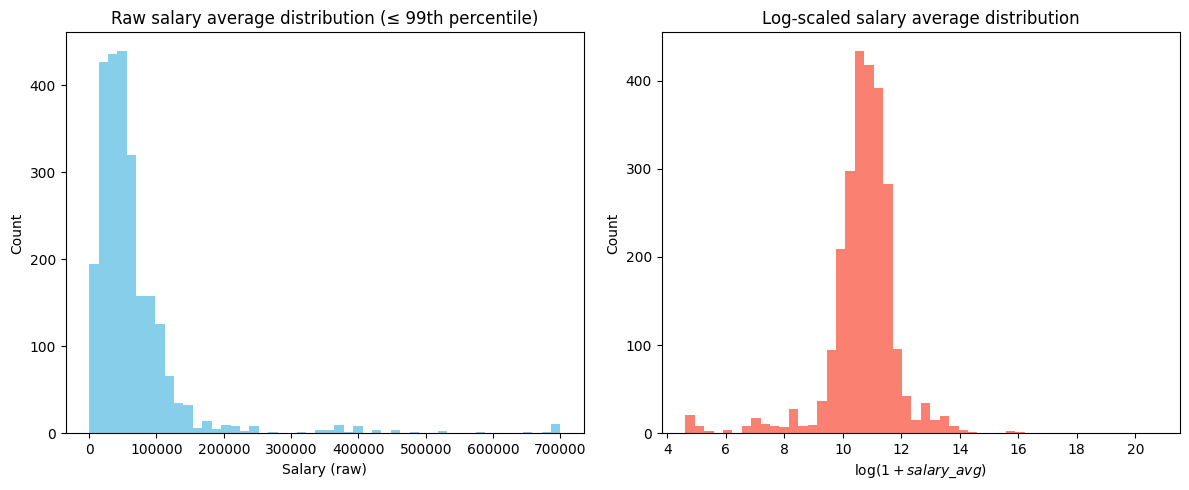

In [ ]:
# create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Raw Distribution (zoomed for readability)
salary_cap = salary_avg_raw.quantile(0.99)

axes[0].hist(
    salary_avg_raw[salary_avg_raw <= salary_cap],
    bins=50,
    color='skyblue'
)
# 99th percentile: preserves almost all data while preventing a few extreme values from dominating the visualization
axes[0].set_title("Raw salary average distribution (≤ 99th percentile)")
axes[0].set_xlabel("Salary (raw)")
axes[0].set_ylabel("Count")



# Plot 2: Log-scaled Distribution
# use $\log(1 + salary\_avg)$ in LaTeX for the label
axes[1].hist(np.log1p(salary_avg_raw), bins=50, color='salmon')
axes[1].set_title("Log-scaled salary average distribution")
axes[1].set_xlabel(r"$\log(1 + salary\_avg)$")
axes[1].set_ylabel("Count")

# adjust layout to prevent label overlapping
plt.tight_layout()

# save the combined figure for EDA
plt.savefig(
    os.path.join(EDA_BEFORE_DIR, "01_raw_vs_log_salary_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Exploratory analysis on left shows strong right skewness, most salaries cluster between 30k to 120k,  motivating log transformation of engineered salary features.

Formula use: log(1+salary_avg)

Raw salary	log(1 + salary)
30,000	≈ 10.31
100,000	≈ 11.51
1,000,000	≈ 13.82
1,000,000,000	≈ 20.72

use log1p to avoid undefined values when salary is zero


**Missing Value**

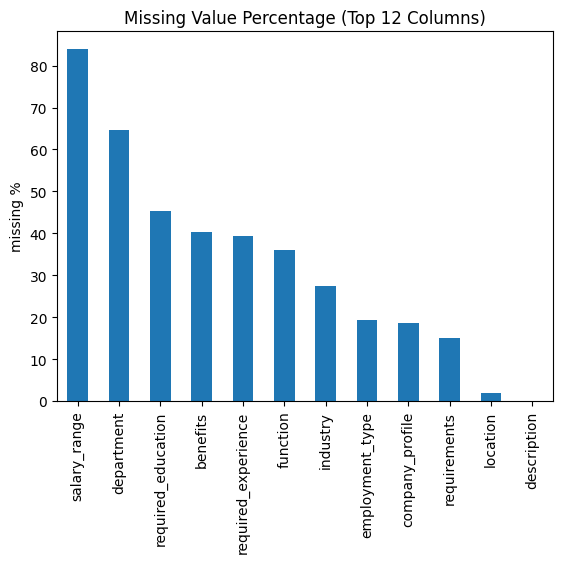

In [11]:
miss = (df.isna().mean()*100).sort_values(ascending=False).head(12)
plt.figure()
miss.plot(kind="bar")
plt.title("Missing Value Percentage (Top 12 Columns)")
plt.ylabel("missing %")

plt.savefig(
    os.path.join(EDA_BEFORE_DIR, "02_missing_value_percentage.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Class Imbalance**

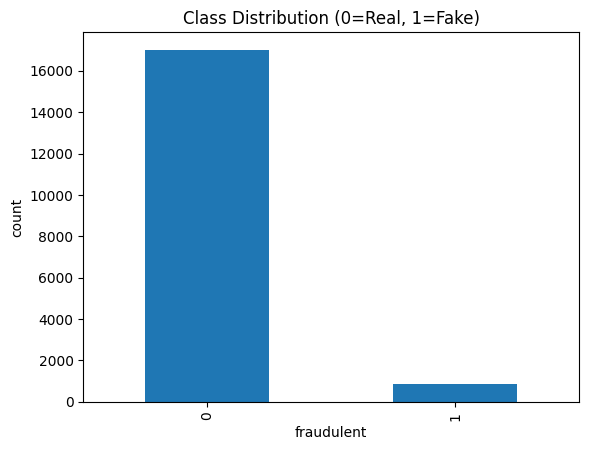

In [12]:
plt.figure()
df["fraudulent"].value_counts().plot(kind="bar")
plt.title("Class Distribution (0=Real, 1=Fake)")
plt.xlabel("fraudulent")
plt.ylabel("count")

plt.savefig(
    os.path.join(EDA_BEFORE_DIR, "03_class_distribution_real_vs_fake.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The dataset is highly imbalanced, requiring stratified sampling and class-weighted models.

# **Data Preparation**

## 3. Data Preparation (Cleaning + Feature Engineering + Export)

### Download NLTK resources

In [5]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith("J"): return "a"
    if tag.startswith("V"): return "v"
    if tag.startswith("N"): return "n"
    if tag.startswith("R"): return "r"
    return "n"

### Text cleaning functions (ML vs DL)

In [6]:
def clean_text_for_ml(text):
    """Heavy cleaning for TF-IDF models."""
    if not isinstance(text, str) or not text.strip():
        return ""

    text = contractions.fix(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if not text:
        return ""

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    if not tokens:
        return ""

    pos_tags = nltk.pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(w, get_wordnet_pos(p)) for w, p in pos_tags]
    return " ".join(lemmas)

def clean_text_for_dl(text):
    """Light cleaning for BERT (keep punctuation/numbers)."""
    if not isinstance(text, str) or not text.strip():
        return ""

    text = contractions.fix(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s.,!?/-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


### Location + salary parsers (no missing in engineered fields)

In [8]:
USD_TO_MYR = 4.06

def extract_location_features(location):
    if pd.isna(location) or str(location).strip() == "":
        return "unknown", "unknown", "unknown"
    parts = [p.strip().lower() for p in str(location).split(",") if p.strip()]
    # common: "US, NY, New York"
    if len(parts) >= 3:
        return parts[-1], parts[-2], parts[0]
    if len(parts) == 2:
        return parts[-1], parts[0], "unknown"
    if len(parts) == 1:
        return parts[0], "unknown", "unknown"
    return "unknown", "unknown", "unknown"

def extract_salary_usd_to_myr(salary_range):
    if pd.isna(salary_range) or str(salary_range).strip() == "":
        return 0.0, 0.0, "myr", 0

    s = str(salary_range)

    nums = re.findall(r"\d+(?:,\d{3})*(?:\.\d+)?", s)
    if len(nums) == 0:
        return 0.0, 0.0, "myr", 0  # handles 9-Dec, Oct-15, etc

    vals = [float(x.replace(",", "")) for x in nums]

    if len(vals) == 1:
        smin = smax = vals[0]
    else:
        smin, smax = vals[0], vals[1]
        if smin > smax:
            smin, smax = smax, smin

    # ASSUME DATASET SALARY IS USD → CONVERT TO RM
    smin *= USD_TO_MYR
    smax *= USD_TO_MYR

    return float(smin), float(smax), "myr", 1


### Main preprocessing pipeline (ALL columns included)

This section:

- drops job_id (identifier)

- fills missing values

- creates text, clean_text, clean_text_dl

- creates engineered structured fields (salary/location)

- ensures no missing in engineered fields


In [ ]:
def build_combined_text(row):
    # include all text columns
    fields = ["title", "location", "department", "company_profile", "description", "requirements", "benefits"]
    parts = []
    for f in fields:
        val = row.get(f, "")
        if isinstance(val, str) and val.strip():
            parts.append(val.strip())
    return ". ".join(parts)

def preprocess_dataset(df_raw):
    dfp = df_raw.copy()

    # 1) Drop ID
    if "job_id" in dfp.columns:
        dfp = dfp.drop(columns=["job_id"])

    # 2) Ensure correct types + fill missing
    text_cols = ["title","location","department","salary_range","company_profile","description","requirements","benefits"]
    for c in text_cols:
        if c in dfp.columns:
            dfp[c] = dfp[c].fillna("").astype(str)

    cat_cols = ["employment_type","required_experience","required_education","industry","function"]
    for c in cat_cols:
        if c in dfp.columns:
            dfp[c] = dfp[c].fillna("Unknown").astype(str)

    # 3) Binary cols
    for b in ["telecommuting","has_company_logo","has_questions"]:
        if b in dfp.columns:
            dfp[b] = pd.to_numeric(dfp[b], errors="coerce").fillna(0).astype(int)

    # 4) Location features
    loc_feat = dfp["location"].apply(lambda x: pd.Series(extract_location_features(x)))
    loc_feat.columns = ["city","state","country"]
    dfp = pd.concat([dfp, loc_feat], axis=1)

    # 5) Salary features

    sal_feat = dfp["salary_range"].apply(lambda x: pd.Series(extract_salary_usd_to_myr(x)))
    sal_feat.columns = ["salary_min", "salary_max", "currency", "has_salary"]
    dfp = pd.concat([dfp, sal_feat], axis=1)


    # ensure salary_min <= salary_max
    swap_mask = dfp["salary_min"] > dfp["salary_max"]
    dfp.loc[swap_mask, ["salary_min","salary_max"]] = (
        dfp.loc[swap_mask, ["salary_max","salary_min"]].values
    )

    # salary engineered + log transform
    dfp["salary_avg"] = (dfp["salary_min"] + dfp["salary_max"]) / 2.0
    dfp["salary_span"] = (dfp["salary_max"] - dfp["salary_min"]).clip(lower=0)
    dfp["log_salary_avg"] = np.log1p(dfp["salary_avg"])
    dfp["log_salary_span"] = np.log1p(dfp["salary_span"])

    # 6) Combine text 
    dfp["text"] = dfp.apply(build_combined_text, axis=1)
    dfp["clean_text"] = dfp["text"].apply(clean_text_for_ml)
    dfp["clean_text_dl"] = dfp["text"].apply(clean_text_for_dl)

    # 7) Remove duplicates
    # remove duplicate job descriptions (covers ML & DL)
    dfp = dfp.drop_duplicates(subset=["text"]).reset_index(drop=True)

    # 8) Text-length features
    dfp["text_length"] = dfp["text"].str.len()
    dfp["word_count"] = dfp["clean_text"].str.split().str.len().fillna(0).astype(int)
    dfp["log_word_count"] = np.log1p(dfp["word_count"])
    dfp["has_company_profile"] = (dfp["company_profile"].str.strip() != "").astype(int)
    dfp["has_requirements"] = (dfp["requirements"].str.strip() != "").astype(int)
    dfp["has_benefits"] = (dfp["benefits"].str.strip() != "").astype(int)
    dfp["title_length"] = dfp["title"].str.len()


    # 9) Remove rows with empty cleaned text (cannot model)
    before = len(dfp)
    dfp = dfp[dfp["clean_text"].str.len() > 0].copy()
    print(f"Removed {before - len(dfp)} rows with empty clean_text")

    # 10) Final “no missing in key engineered fields”
    key_cols = [
        "city","state","country",
        "salary_min","salary_max","currency",
        "has_salary","log_salary_avg","log_salary_span",
        "has_company_profile","has_requirements","has_benefits","title_length",
        "clean_text","clean_text_dl","log_word_count"
    ]
    for c in key_cols:
        if c in dfp.columns:
            dfp[c] = dfp[c].fillna("unknown") if dfp[c].dtype == "object" else dfp[c].fillna(0)

    return dfp

df_clean = preprocess_dataset(df)
print("Cleaned shape:", df_clean.shape)
display(df_clean.head(3))

df_clean.info()
display(audit_table(df_clean).head(15))
print("\nAny NaN left?", df_clean.isna().sum().sum())


Removed 0 rows with empty clean_text
Cleaned shape: (17468, 38)


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,...,text,clean_text,clean_text_dl,text_length,word_count,log_word_count,has_company_profile,has_requirements,has_benefits,title_length
0,Marketing Intern,"US, NY, New York",Marketing,,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,...,"Marketing Intern. US, NY, New York. Marketing....",market intern new york marketing food create g...,"marketing intern. us, ny, new york. marketing....",2693,254,5.541264,1,1,0,16
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,...,"Customer Service - Cloud Video Production. NZ,...",customer service cloud video production auckla...,"customer service - cloud video production. nz,...",6160,518,6.251904,1,1,1,41
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",,,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,...,"Commissioning Machinery Assistant (CMA). US, I...",commission machinery assistant cma wever valor...,"commissioning machinery assistant cma . us, ia...",2656,234,5.459586,1,1,0,39


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17468 entries, 0 to 17467
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                17468 non-null  object 
 1   location             17468 non-null  object 
 2   department           17468 non-null  object 
 3   salary_range         17468 non-null  object 
 4   company_profile      17468 non-null  object 
 5   description          17468 non-null  object 
 6   requirements         17468 non-null  object 
 7   benefits             17468 non-null  object 
 8   telecommuting        17468 non-null  int64  
 9   has_company_logo     17468 non-null  int64  
 10  has_questions        17468 non-null  int64  
 11  employment_type      17468 non-null  object 
 12  required_experience  17468 non-null  object 
 13  required_education   17468 non-null  object 
 14  industry             17468 non-null  object 
 15  function             17468 non-null 

,dtype,missing_count,missing_pct,unique_non_null
title,object,0,0.0,11229
location,object,0,0.0,3105
department,object,0,0.0,1338
salary_range,object,0,0.0,872
company_profile,object,0,0.0,1710
description,object,0,0.0,14778
requirements,object,0,0.0,11961
benefits,object,0,0.0,6203
telecommuting,int64,0,0.0,2
has_company_logo,int64,0,0.0,2



Any NaN left? 0


### Pipeline Wrapper

In [20]:
class FullPreprocessTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return preprocess_dataset(X)

In [21]:
# build df_clean via preprocess pipeline
preprocess_pipe = FullPreprocessTransformer()
df_clean = preprocess_pipe.transform(df)
print("✔️ Preprocessing done (df_clean created). Pipeline is used for training only")

Removed 0 rows with empty clean_text
✔️ Preprocessing done (df_clean created). Pipeline is used for training only


### Export cleaned dataset + quality summary

In [23]:
df_clean.to_csv(CLEAN_PATH, index=False)
print("Saved:", CLEAN_PATH)

summary = {
    "rows": int(df_clean.shape[0]),
    "cols": int(df_clean.shape[1]),
    "target_counts": df_clean["fraudulent"].value_counts().to_dict(),
    "target_pct": (df_clean["fraudulent"].value_counts(normalize=True)*100).round(2).to_dict(),
    "missing_total": int(df_clean.isna().sum().sum()),
    "salary_min_nan": int(df_clean["salary_min"].isna().sum()),
    "salary_max_nan": int(df_clean["salary_max"].isna().sum()),
    "city_unknown_rate": float((df_clean["city"] == "unknown").mean()),
    "state_unknown_rate": float((df_clean["state"] == "unknown").mean()),
    "country_unknown_rate": float((df_clean["country"] == "unknown").mean()),
    "salary_missing_rate_original_col": float((df_clean["salary_range"].str.strip() == "").mean()),
    "mean_word_count": float(df_clean["word_count"].mean()),
    "median_word_count": float(df_clean["word_count"].median()),
}
print(json.dumps(summary, indent=2))

Saved: .\data\fake_job_postings_cleaned.csv
{
  "rows": 17468,
  "cols": 38,
  "target_counts": {
    "0": 16615,
    "1": 853
  },
  "target_pct": {
    "0": 95.12,
    "1": 4.88
  },
  "missing_total": 0,
  "salary_min_nan": 0,
  "salary_max_nan": 0,
  "city_unknown_rate": 0.01952141057934509,
  "state_unknown_rate": 0.07825738493244791,
  "country_unknown_rate": 0.18296313258529884,
  "salary_missing_rate_original_col": 0.838962674604992,
  "mean_word_count": 242.6104877490268,
  "median_word_count": 230.0
}


## 4. EDA

In [13]:
df_clean = pd.read_csv(CLEAN_PATH)
print("Loaded cleaned data:", df_clean.shape)
display(df_clean.head())

Loaded cleaned data: (17468, 38)


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,...,text,clean_text,clean_text_dl,text_length,word_count,log_word_count,has_company_profile,has_requirements,has_benefits,title_length
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,...,"Marketing Intern. US, NY, New York. Marketing....",market intern new york marketing food create g...,"marketing intern. us, ny, new york. marketing....",2693,254,5.541264,1,1,0,16
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,...,"Customer Service - Cloud Video Production. NZ,...",customer service cloud video production auckla...,"customer service - cloud video production. nz,...",6160,518,6.251904,1,1,1,41
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,...,"Commissioning Machinery Assistant (CMA). US, I...",commission machinery assistant cma wever valor...,"commissioning machinery assistant cma . us, ia...",2656,234,5.459586,1,1,0,39
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,...,"Account Executive - Washington DC. US, DC, Was...",account executive washington washington sale p...,"account executive - washington dc. us, dc, was...",5493,485,6.186209,1,1,1,33
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,...,"Bill Review Manager. US, FL, Fort Worth. SpotS...",bill review manager fort worth spotsource solu...,"bill review manager. us, fl, fort worth. spots...",3972,350,5.860786,1,1,1,19


In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17468 entries, 0 to 17467
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                17468 non-null  object 
 1   location             17127 non-null  object 
 2   department           6247 non-null   object 
 3   salary_range         2813 non-null   object 
 4   company_profile      14207 non-null  object 
 5   description          17467 non-null  object 
 6   requirements         14831 non-null  object 
 7   benefits             10420 non-null  object 
 8   telecommuting        17468 non-null  int64  
 9   has_company_logo     17468 non-null  int64  
 10  has_questions        17468 non-null  int64  
 11  employment_type      17468 non-null  object 
 12  required_experience  17468 non-null  object 
 13  required_education   17468 non-null  object 
 14  industry             17468 non-null  object 
 15  function             17468 non-null 

### Word count distribution by class

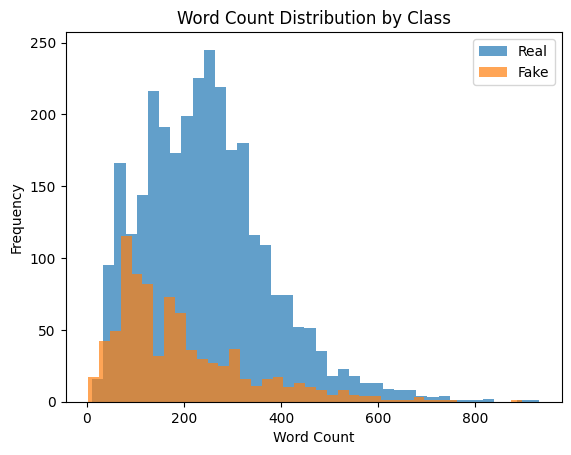

In [15]:
real_wc = df_clean[df_clean["fraudulent"]==0]["word_count"]
fake_wc = df_clean[df_clean["fraudulent"]==1]["word_count"]

plt.figure()
real_wc.sample(min(3000, len(real_wc))).plot(kind="hist", bins=40, alpha=0.7, label="Real")
fake_wc.plot(kind="hist", bins=40, alpha=0.7, label="Fake")
plt.title("Word Count Distribution by Class")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()

plt.savefig(
    os.path.join(EDA_AFTER_DIR, "04_word_count_distribution_by_class.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Fake postings are significantly shorter and less detailed, suggesting low-effort content generation.

### Salary availability vs fraud

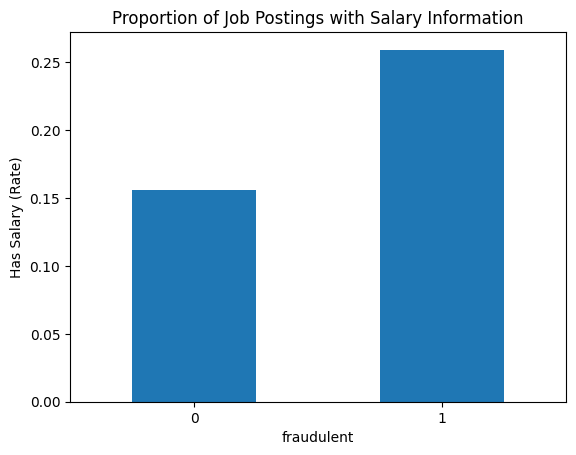

In [16]:
rate = df_clean.groupby("fraudulent")["has_salary"].mean()

plt.figure()
rate.plot(kind="bar")
plt.title("Proportion of Job Postings with Salary Information")
plt.ylabel("Has Salary (Rate)")
plt.xticks(rotation=0)

plt.savefig(
    os.path.join(EDA_AFTER_DIR, "05_job_postings_with_salary_information.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Fake postings are more likely to disclose salary information.
Fake postings often use salary as a lure to attract attention quickly.Real postings may omit salary due to negotiation flexibility, internal HR policy, or legal constraints.

### Company logo vs fraud (legitimacy signal)

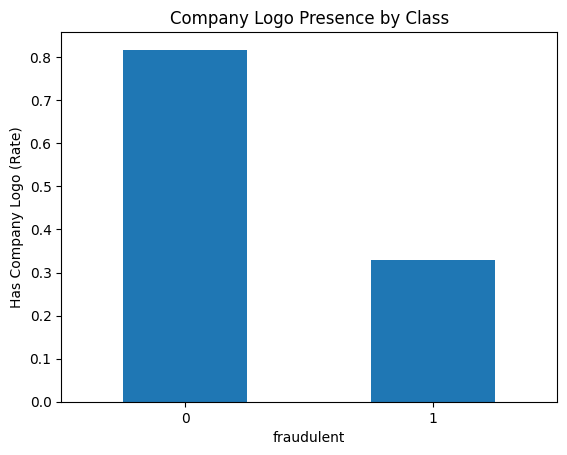

In [17]:
logo_rate = df_clean.groupby("fraudulent")["has_company_logo"].mean()

plt.figure()
logo_rate.plot(kind="bar")
plt.title("Company Logo Presence by Class")
plt.ylabel("Has Company Logo (Rate)")
plt.xticks(rotation=0)

plt.savefig(
    os.path.join(EDA_AFTER_DIR, "06_company_logo_presence_by_class.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Legitimate companies are significantly more likely to provide branding elements such as logos.

### Telecommuting vs fraud (behavioural signal)

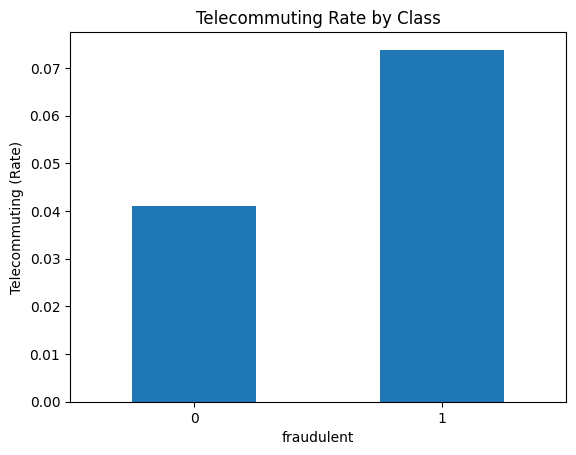

In [18]:
tele_rate = df_clean.groupby("fraudulent")["telecommuting"].mean()

plt.figure()
tele_rate.plot(kind="bar")
plt.title("Telecommuting Rate by Class")
plt.ylabel("Telecommuting (Rate)")
plt.xticks(rotation=0)

plt.savefig(
    os.path.join(EDA_AFTER_DIR, "07_telecommuting_rate_by_class.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Fake postings show a higher tendency to advertise remote work, aligning with common scam strategies.

### Top words in fake vs real postings (TEXTUAL INSIGHT)

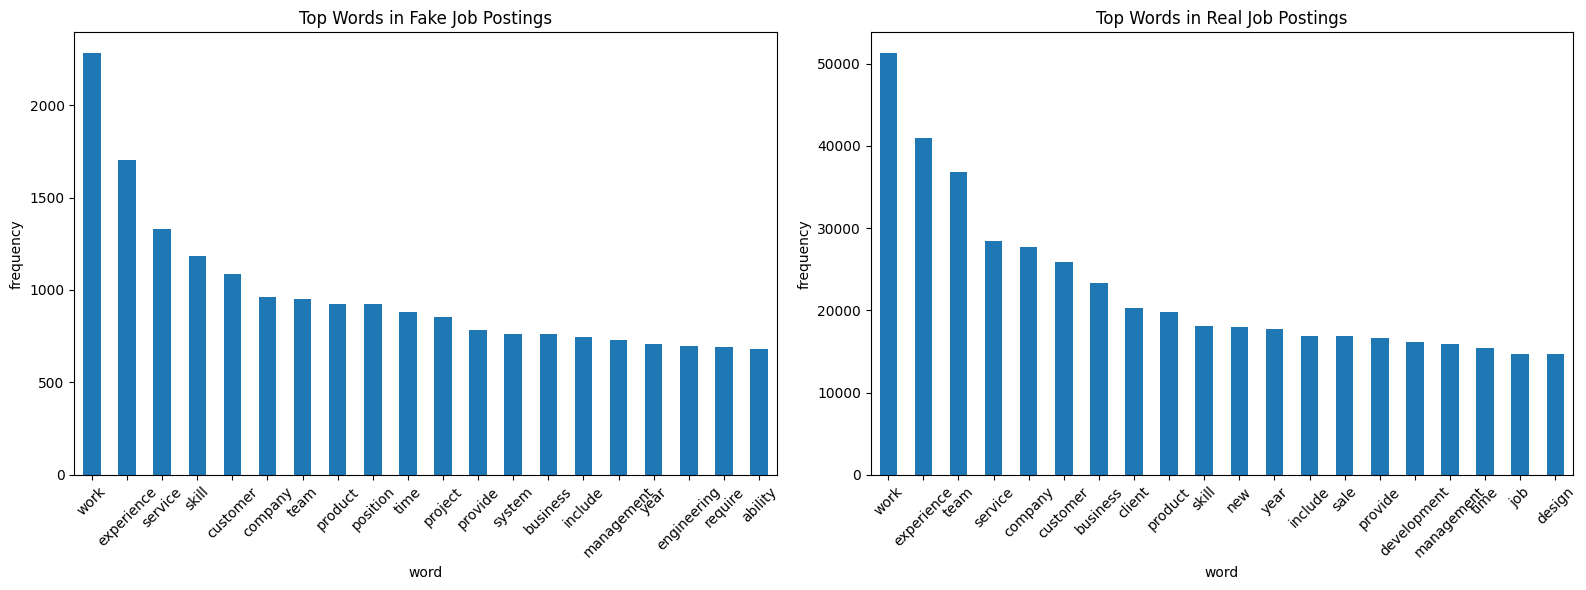

In [19]:
# function to extract top words per class
def top_words(df, label, n=20):
    text = " ".join(df[df["fraudulent"] == label]["clean_text"])
    return Counter(text.split()).most_common(n)

# compute top words
top_fake = top_words(df_clean, 1)
top_real = top_words(df_clean, 0)

# convert to dataframe
fake_df = pd.DataFrame(top_fake, columns=["word", "count"]).set_index("word")
real_df = pd.DataFrame(top_real, columns=["word", "count"]).set_index("word")

# create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# fake postings
fake_df.plot(
    kind="bar",
    ax=axes[0],
    title="Top Words in Fake Job Postings",
    legend=False
)
axes[0].set_xlabel("word")
axes[0].set_ylabel("frequency")
axes[0].tick_params(axis="x", rotation=45)

# real postings
real_df.plot(
    kind="bar",
    ax=axes[1],
    title="Top Words in Real Job Postings",
    legend=False
)
axes[1].set_xlabel("word")
axes[1].set_ylabel("frequency")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(EDA_AFTER_DIR, "08_top_words_real_vs_fake_bar.png.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [20]:
# split text by class using cleaned text
fake_text = " ".join(df_clean.loc[df_clean["fraudulent"] == 1, "clean_text"])
real_text = " ".join(df_clean.loc[df_clean["fraudulent"] == 0, "clean_text"])

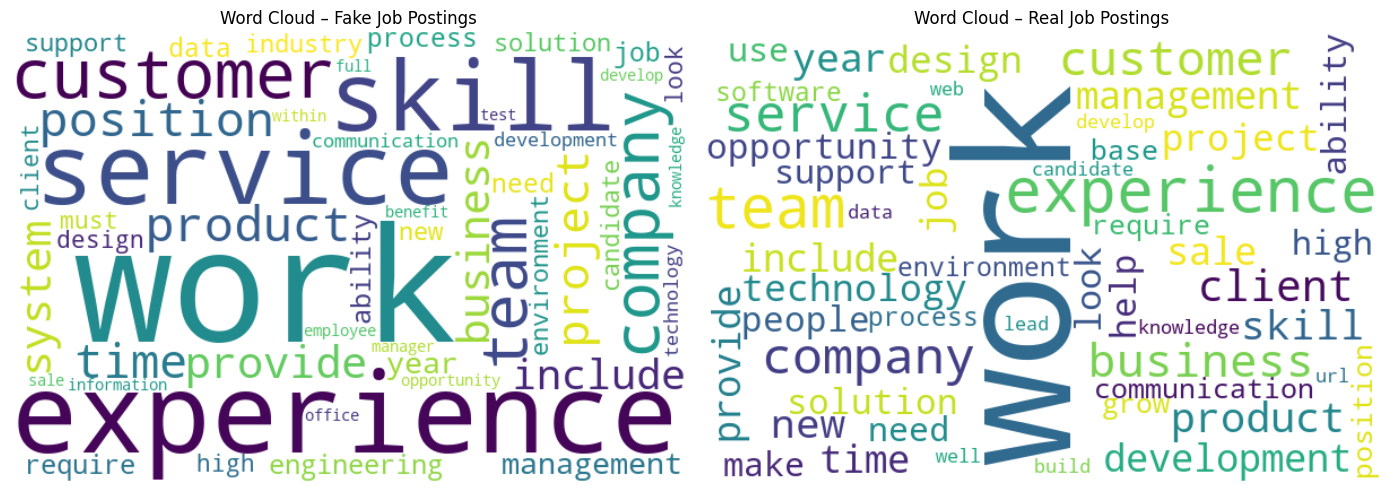

In [22]:
# define common wordcloud settings for fair comparison
wc_settings = dict(
    width=600,
    height=400,
    background_color="white",
    max_words=50,
    collocations=False
)

# generate word clouds
wc_fake = WordCloud(**wc_settings).generate(fake_text)
wc_real = WordCloud(**wc_settings).generate(real_text)

# plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(wc_fake, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud – Fake Job Postings")

axes[1].imshow(wc_real, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud – Real Job Postings")

plt.tight_layout()

plt.savefig(
    os.path.join(EDA_AFTER_DIR, "09_top_words_real_vs_fake_wordcloud.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Fake postings tend to use generic, non-specific language and broad skill references without concrete role detail. This kind of wording is easy to reuse across many scams.

Real postings are more role-specific, reference organizational functions, products, and processes. Language is more concrete and contextual.

### Boxplot: text length vs class

<Figure size 640x480 with 0 Axes>

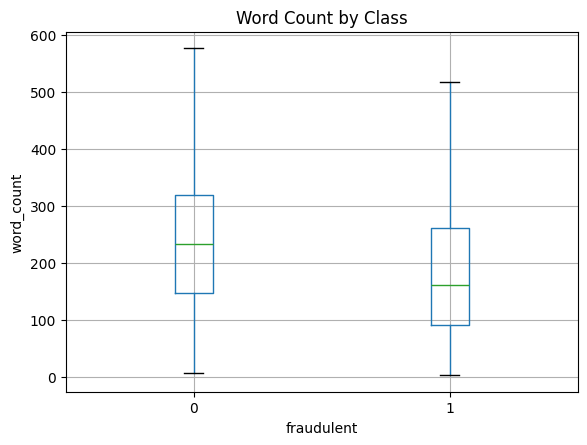

In [23]:
plt.figure()
df_clean.boxplot(
    column="word_count",
    by="fraudulent",
    showfliers=False
)
plt.title("Word Count by Class")
plt.suptitle("")
plt.xlabel("fraudulent")
plt.ylabel("word_count")

plt.savefig(
    os.path.join(EDA_AFTER_DIR, "10_word_count_by_class_boxplot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Median word count for fake postings is substantially lower, reinforcing text richness as a discriminative feature.

### Employment type distribution (categorical insight)

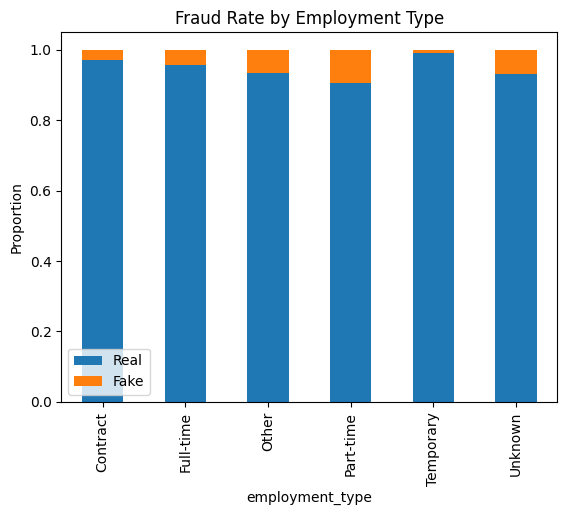

In [24]:
pd.crosstab(
    df_clean["employment_type"],
    df_clean["fraudulent"],
    normalize="index"
).plot(kind="bar", stacked=True)

plt.title("Fraud Rate by Employment Type")
plt.ylabel("Proportion")
plt.legend(["Real", "Fake"])

plt.savefig(
    os.path.join(EDA_AFTER_DIR, "11_fraud_rate_by_employment_type.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Fraudulent postings are observed across all categories, higher fraud proportions are evident in part-time and ambiguously defined roles (e.g., “Other” or “Unknown”). This suggests that vague employment arrangements may be exploited by scammers, reinforcing the importance of structured metadata features in fraudulent job detection.

### Correlation heatmap (structured features only)

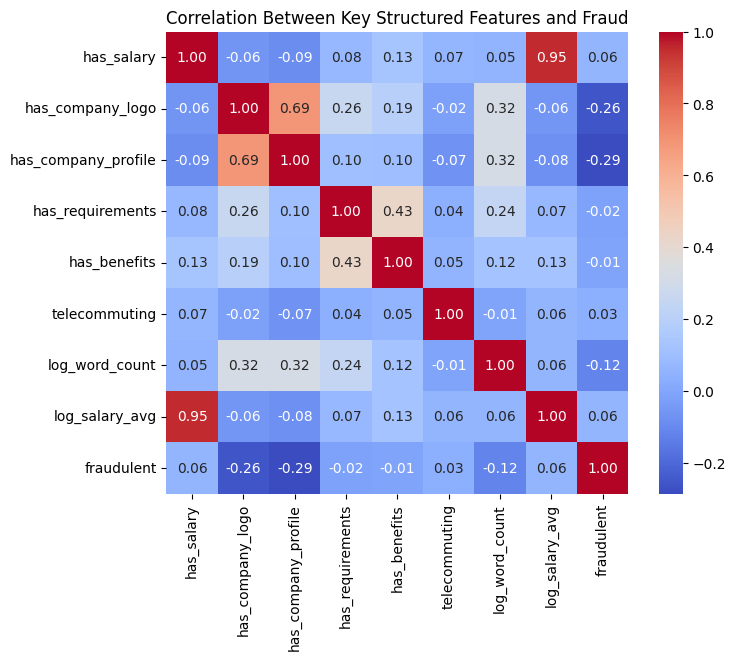

In [25]:
corr_cols = [
    "has_salary",
    "has_company_logo",
    "has_company_profile",
    "has_requirements",
    "has_benefits",
    "telecommuting",
    "log_word_count",
    "log_salary_avg",
    "fraudulent"
]


plt.figure(figsize=(8,6))
sns.heatmap(
    df_clean[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Correlation Between Key Structured Features and Fraud")

plt.savefig(
    os.path.join(EDA_AFTER_DIR, "12_correlation_structured_features_vs_fraud.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()



The presence of a company logo and higher text length are negatively correlated with fraudulent postings, while salary disclosure shows a weak positive association. Overall, correlations are moderate, indicating that no single feature is sufficient for reliable detection. This supports the need for a combined text-based and metadata-driven classification framework.

# **Modelling**

## 5. Encoding

### Define ALL feature groups

In [7]:
# if need to rerun code
df_clean = pd.read_csv(CLEAN_PATH)

In [ ]:
# Target
y = df_clean["fraudulent"].astype(int).values

# TEXT fields
text_col_ml = "clean_text"       # heavy clean for TF-IDF & Word2Vec
text_col_dl = "clean_text_dl"    # light clean for BERT


# Structured feature groups
# Binary (original + engineered)
binary_cols = [
    "telecommuting", "has_company_logo", "has_questions", "has_salary",
    "has_company_profile", "has_requirements", "has_benefits"
]

# Numeric engineered (log transforms help stability / outliers)
numeric_cols = [
    "log_salary_avg", "log_salary_span", "log_word_count",
    "text_length", "title_length"
]

# Low-card categorical → OneHot (avoid ordinal meaning)
low_card_cols = [
    "employment_type", "required_experience",
    "required_education", "currency", "department"
]

# High-card categorical → LabelEncode (compact for many unique values)
high_card_cols = ["city", "state", "country", "industry", "function"]


# Keep only columns that exist (prevents notebook break)
binary_cols = [c for c in binary_cols if c in df_clean.columns]
numeric_cols = [c for c in numeric_cols if c in df_clean.columns]
low_card_cols = [c for c in low_card_cols if c in df_clean.columns]
high_card_cols = [c for c in high_card_cols if c in df_clean.columns]

print("Binary:", binary_cols)
print("Numeric:", numeric_cols)
print("Low-card:", low_card_cols)
print("High-card:", high_card_cols)

# Quick sanity
print("\nCheck missing values in key columns:")
display(df_clean[binary_cols + numeric_cols + low_card_cols + high_card_cols].isna().sum().sort_values(ascending=False).head(15))

Binary: ['telecommuting', 'has_company_logo', 'has_questions', 'has_salary', 'has_company_profile', 'has_requirements', 'has_benefits']
Numeric: ['log_salary_avg', 'log_salary_span', 'log_word_count', 'text_length', 'title_length']
Low-card: ['employment_type', 'required_experience', 'required_education', 'currency', 'department']
High-card: ['city', 'state', 'country', 'industry', 'function']

Check missing values in key columns:


department             11221
telecommuting              0
has_questions              0
has_salary                 0
has_company_profile        0
has_company_logo           0
has_requirements           0
has_benefits               0
log_salary_span            0
log_salary_avg             0
text_length                0
title_length               0
employment_type            0
log_word_count             0
required_experience        0
dtype: int64

### Encode structured features (scale + OHE + LabelEncode)

In [ ]:
df_enc = df_clean.copy()

# scale numeric 
scaler = StandardScaler()
df_enc[numeric_cols] = scaler.fit_transform(df_enc[numeric_cols].astype(float))

# one-hot for low-card 
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
ohe_arr = ohe.fit_transform(df_enc[low_card_cols])
ohe_df = pd.DataFrame(
    ohe_arr,
    columns=ohe.get_feature_names_out(low_card_cols),
    index=df_enc.index
)

# label encode for high-card 
label_encoders = {}
for col in high_card_cols:
    df_enc[col] = df_enc[col].astype(str)
    df_enc.loc[df_enc.index[0], col] = "unknown"
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    label_encoders[col] = le

# Structured base features (non-text)
structured_base = binary_cols + numeric_cols + high_card_cols
X_structured = pd.concat([df_enc[structured_base], ohe_df], axis=1)

# Sparse version (can hstack with TF-IDF)
X_structured_sp = csr_matrix(X_structured.values)

print("Structured matrix shape:", X_structured.shape)


Structured matrix shape: (17468, 1379)


In [10]:
assert X_structured.shape[0] == df_clean.shape[0], "Row count mismatch: structured vs df_clean"
assert (X_structured.index.values == df_clean.index.values).all(), "Index mismatch: structured vs df_clean"
print("✅ Row alignment OK (df_clean ↔ X_structured_sp)")

# Save feature groups for deployment
feature_groups = {
    "binary_cols": binary_cols,
    "numeric_cols": numeric_cols,
    "low_card_cols": low_card_cols,
    "high_card_cols": high_card_cols
}

✅ Row alignment OK (df_clean ↔ X_structured_sp)


## 6. Modeling

### **6.0 Shared Train/Val/Test Split (ONE split for ALL models)**

In [ ]:
# one shared split for every model (TF-IDF, Word2Vec, DistilBERT)
idx = np.arange(len(df_clean))
y_all = df_clean["fraudulent"].astype(int).values

# split out TEST first (20%)
idx_trainval, idx_test = train_test_split(
    idx,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

# split TRAIN vs VAL from remaining 80%
# VAL should be 20% of total -> 0.20 / 0.80 = 0.25 of trainval
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=0.25,          # 25% of 80% = 20% of total
    random_state=SEED,
    stratify=y_all[idx_trainval]
)

print("Train size:", len(idx_train), "Val size:", len(idx_val), "Test size:", len(idx_test))
print("Fraud rate train:", round(y_all[idx_train].mean(), 4),
      "val:", round(y_all[idx_val].mean(), 4),
      "test:", round(y_all[idx_test].mean(), 4))

print("\nTrain label counts:\n", pd.Series(y_all[idx_train]).value_counts())
print("\nVal label counts:\n", pd.Series(y_all[idx_val]).value_counts())
print("\nTest label counts:\n", pd.Series(y_all[idx_test]).value_counts())

Train size: 10480 Val size: 3494 Test size: 3494
Fraud rate train: 0.0488 val: 0.0489 test: 0.0489

Train label counts:
 0    9969
1     511
Name: count, dtype: int64

Val label counts:
 0    3323
1     171
Name: count, dtype: int64

Test label counts:
 0    3323
1     171
Name: count, dtype: int64


In [ ]:
# helper function for better threshold tuning


def tune_threshold_on_val(y_val, proba_val, metric="f1"):
    thresholds = np.linspace(0.01, 0.99, 199)
    best = {"t": 0.5, "f1": -1, "precision": 0, "recall": 0}

    for t in thresholds:
        pred = (proba_val >= t).astype(int)
        p = precision_score(y_val, pred, zero_division=0)
        r = recall_score(y_val, pred, zero_division=0)
        f1 = f1_score(y_val, pred, zero_division=0)

        # choose by metric (default f1)
        score = f1 if metric == "f1" else (p if metric == "precision" else r)
        best_score = best["f1"] if metric == "f1" else (best["precision"] if metric == "precision" else best["recall"])

        if score > best_score:
            best = {"t": float(t), "f1": float(f1), "precision": float(p), "recall": float(r)}

    return best

### **6.1 Classical Feature-based Models (TF-IDF)**

**Feature construction (shared TF-IDF representation)**

In [ ]:
# TF-IDF tuned for fraud detection (NO leakage)
tfidf = TfidfVectorizer(
    max_features=120_000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32
)

# fit ONLY on TRAIN 
X_text_train = tfidf.fit_transform(
    df_clean.iloc[idx_train][text_col_ml].astype(str)
)

# transform VAL & TEST 
X_text_val = tfidf.transform(
    df_clean.iloc[idx_val][text_col_ml].astype(str)
)

X_text_test = tfidf.transform(
    df_clean.iloc[idx_test][text_col_ml].astype(str)
)

# stack structured features
X_train = hstack([X_text_train, X_structured_sp[idx_train]]).tocsr()
X_val   = hstack([X_text_val,   X_structured_sp[idx_val]]).tocsr()
X_test  = hstack([X_text_test,  X_structured_sp[idx_test]]).tocsr()

y_train = y_all[idx_train]
y_val   = y_all[idx_val]
y_test  = y_all[idx_test]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (10480, 121379) Val: (3494, 121379) Test: (3494, 121379)


In [21]:
# save if need to rerun lime code
tfidf_save_path = os.path.join(EVAL_DIR, "tfidf.joblib")
joblib.dump(tfidf, tfidf_save_path)

print(f"✔️ TF-IDF vectorizer saved to: {tfidf_save_path}")

✔️ TF-IDF vectorizer saved to: .\artifacts_eval\tfidf.joblib


In [22]:
# Class imbalance summary
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
imbalance_ratio = neg / pos

print("Negative (Real):", neg)
print("Positive (Fake):", pos)
print("Imbalance ratio (neg/pos):", round(imbalance_ratio, 2))

Negative (Real): 9969
Positive (Fake): 511
Imbalance ratio (neg/pos): 19.51


**Logistic Regression (optimized for explainability)**

In [41]:
lr = LogisticRegression(max_iter=8000, class_weight="balanced", C=1.0, n_jobs=-1, random_state=SEED)
lr.fit(X_train, y_train)

proba_lr_val = lr.predict_proba(X_val)[:, 1]
best_lr = tune_threshold_on_val(y_val, proba_lr_val, metric="f1")
best_t_lr = best_lr["t"]
print("Best LR (val):", best_lr)

proba_lr_test = lr.predict_proba(X_test)[:, 1]
y_pred_lr_test = (proba_lr_test >= best_t_lr).astype(int)

Best LR (val): {'t': 0.8019191919191919, 'f1': 0.7935483870967742, 'precision': 0.8848920863309353, 'recall': 0.7192982456140351}


**Linear SVM (precision-oriented baseline)**

In [42]:
svm = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", max_iter=30000, tol=1e-3),
    method="sigmoid"
)
svm.fit(X_train, y_train)

proba_svm_val = svm.predict_proba(X_val)[:, 1]
best_svm = tune_threshold_on_val(y_val, proba_svm_val, metric="f1")
best_t_svm = best_svm["t"]
print("Best SVM (val):", best_svm)

proba_svm_test = svm.predict_proba(X_test)[:, 1]
y_pred_svm_test = (proba_svm_test >= best_t_svm).astype(int)

C:\Users\xinph\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\xinph\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\xinph\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\xinph\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear 

Best SVM (val): {'t': 0.23767676767676768, 'f1': 0.5882352941176471, 'precision': 0.6666666666666666, 'recall': 0.5263157894736842}


**Random Forest (non-linear baseline)**

In [43]:
rf = RandomForestClassifier(
    n_estimators=700,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)

proba_rf_val = rf.predict_proba(X_val)[:, 1]
best_rf = tune_threshold_on_val(y_val, proba_rf_val, metric="f1")  # changes 1
best_t_rf = best_rf["t"]
print("Best RF (val):", best_rf)

proba_rf_test = rf.predict_proba(X_test)[:, 1]
y_pred_rf_test = (proba_rf_test >= best_t_rf).astype(int)


Best RF (val): {'t': 0.4406060606060606, 'f1': 0.8106312292358804, 'precision': 0.9384615384615385, 'recall': 0.7134502923976608}


**XGBoost (high-performance fraud detector)**

In [44]:
xgb = XGBClassifier(
    n_estimators=5000,
    max_depth=8,
    min_child_weight=2,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.05,
    reg_alpha=0.2,
    reg_lambda=2.0,

    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=SEED,
    n_jobs=-1,

    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    tree_method="hist",          # change to "gpu_hist" if GPU works
    max_bin=256,
    early_stopping_rounds=100
)


xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_n = (xgb.best_iteration + 1) if xgb.best_iteration is not None else xgb.n_estimators
print("Best iteration:", xgb.best_iteration)
print("Best score:", xgb.best_score)
print("best_n:", best_n)

proba_xgb_val = xgb.predict_proba(X_val)[:, 1]
best_xgb = tune_threshold_on_val(y_val, proba_xgb_val, metric="f1")
best_t_xgb = best_xgb["t"]
print("Best XGB (val):", best_xgb)

proba_xgb_test = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb_test = (proba_xgb_test >= best_t_xgb).astype(int)

Best iteration: 991
Best score: 0.9082916310223794
best_n: 992
Best XGB (val): {'t': 0.46535353535353535, 'f1': 0.8641975308641975, 'precision': 0.9150326797385621, 'recall': 0.8187134502923976}


### **6.2 Embedding-based Model (Word2Vec)**

In [ ]:
# Word2Vec + LR

# 1) Split text using your shared indices (no leakage)
texts_all = df_clean[text_col_ml].astype(str).values

X_train_txt = texts_all[idx_train]
X_val_txt   = texts_all[idx_val]
X_test_txt  = texts_all[idx_test]

y_train_w2v = y_all[idx_train]
y_val_w2v   = y_all[idx_val]
y_test_w2v  = y_all[idx_test]

# 2) Tokenize ONCE (speed-up)
train_tokens = [t.split() for t in X_train_txt]
val_tokens   = [t.split() for t in X_val_txt]
test_tokens  = [t.split() for t in X_test_txt]

# 3) Train Word2Vec ONLY on TRAIN tokens (no leakage)
w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=300,
    window=5,
    min_count=2,
    workers=os.cpu_count(),
    sg=1,            # skip-gram
    negative=10,
    epochs=5,        
    seed=SEED
)

# 4) Fast mean-pooling (same output logic, faster)
def avg_w2v_vector(tokens, model):
    toks = [w for w in tokens if w in model.wv]
    if not toks:
        return np.zeros(model.vector_size, dtype=np.float32)
    return model.wv[toks].mean(axis=0)

# 5) Build vectors (still exact same idea: mean of word vectors)
X_train_w2v = np.vstack([avg_w2v_vector(toks, w2v) for toks in train_tokens])
X_val_w2v   = np.vstack([avg_w2v_vector(toks, w2v) for toks in val_tokens])
X_test_w2v  = np.vstack([avg_w2v_vector(toks, w2v) for toks in test_tokens])

print("Word2Vec vectors:",
      "Train", X_train_w2v.shape,
      "| Val", X_val_w2v.shape,
      "| Test", X_test_w2v.shape)

# 6) Classifier on TRAIN (balanced for imbalance)
lr_w2v = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED,
    solver="lbfgs"
)
lr_w2v.fit(X_train_w2v, y_train_w2v)

# 7) Tune threshold on VAL
proba_w2v_val = lr_w2v.predict_proba(X_val_w2v)[:, 1]
best_w2v = tune_threshold_on_val(y_val_w2v, proba_w2v_val, metric="f1")
best_t_w2v = best_w2v["t"]
print("Best Word2Vec+LR (val):", best_w2v)

# 8) Final TEST prediction using fixed threshold
proba_w2v_test = lr_w2v.predict_proba(X_test_w2v)[:, 1]
y_pred_w2v_test = (proba_w2v_test >= best_t_w2v).astype(int)


Word2Vec vectors: Train (10480, 300) | Val (3494, 300) | Test (3494, 300)
Best Word2Vec+LR (val): {'t': 0.7573737373737374, 'f1': 0.5942857142857143, 'precision': 0.5810055865921788, 'recall': 0.6081871345029239}


### **6.3 Transformer-based Model (DistilBERT)**


In [ ]:
# Seed + token
set_seed(SEED)
HF_TOKEN = os.environ.get("HUGGINGFACE_TOKEN", None)


# 1) Prepare splits 
X_dl_all = df_clean[text_col_dl].astype(str).values

X_train_dl = X_dl_all[idx_train]
X_val_dl   = X_dl_all[idx_val]
X_test_dl  = X_dl_all[idx_test]

y_train_dl = y_all[idx_train].astype(int)
y_val_dl   = y_all[idx_val].astype(int)
y_test_dl  = y_all[idx_test].astype(int)

train_ds = Dataset.from_dict({"text": X_train_dl, "labels": y_train_dl})
val_ds   = Dataset.from_dict({"text": X_val_dl,   "labels": y_val_dl})
test_ds  = Dataset.from_dict({"text": X_test_dl,  "labels": y_test_dl})


# 2) Tokenize + dynamic padding collator
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

train_ds = train_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
val_ds   = val_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize_batch, batched=True, remove_columns=["text"])

train_ds.set_format("torch", ["input_ids", "attention_mask", "labels"])
val_ds.set_format("torch", ["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", ["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# 3) Model
bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, token=HF_TOKEN
)


# 4) Class weights (imbalance handling)
counts = np.bincount(y_train_dl, minlength=2)
w0 = 1.0
w1 = counts[0] / counts[1]
class_weights = torch.tensor([w0, w1], dtype=torch.float)


# 5) Weighted Trainer 
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

# 6) Training args 
training_args = TrainingArguments(
    output_dir="./bert_out",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,

    learning_rate=2e-5,
    num_train_epochs=2,
    weight_decay=0.01,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=100,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = WeightedTrainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,     
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

# 7) Train
trainer.train()

# 8) Threshold tuning on VAL + final TEST eval
def best_threshold_f1(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    best_t, best_f1 = 0.5, -1.0
    for t in np.linspace(0.01, 0.99, 99):
        f = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1

# VAL probs
val_out = trainer.predict(val_ds)
val_probs = torch.softmax(torch.tensor(val_out.predictions), dim=1).numpy()[:, 1]
best_t, best_val_f1 = best_threshold_f1(y_val_dl, val_probs)

print("\nBest threshold (VAL):", best_t)
print("Best VAL F1:", best_val_f1)
print("VAL PR AUC:", average_precision_score(y_val_dl, val_probs))
print("VAL ROC AUC:", roc_auc_score(y_val_dl, val_probs))

# TEST probs + tuned threshold
test_out = trainer.predict(test_ds)
test_probs = torch.softmax(torch.tensor(test_out.predictions), dim=1).numpy()[:, 1]
test_pred = (test_probs >= best_t).astype(int)

print("\n===== DistilBERT FINAL (threshold tuned on VAL) =====")
print("TEST Precision:", precision_score(y_test_dl, test_pred, zero_division=0))
print("TEST Recall:", recall_score(y_test_dl, test_pred, zero_division=0))
print("TEST F1:", f1_score(y_test_dl, test_pred, zero_division=0))
print("TEST PR AUC:", average_precision_score(y_test_dl, test_probs))
print("TEST ROC AUC:", roc_auc_score(y_test_dl, test_probs))

bert_prob_fake_test = test_probs
bert_preds_test = test_pred
print("DistilBERT test prob shape:", bert_prob_fake_test.shape)


Map:   0%|          | 0/10480 [00:00<?, ? examples/s]

Map:   0%|          | 0/3494 [00:00<?, ? examples/s]

Map:   0%|          | 0/3494 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.433100,0.606442,0.982255,0.916031,0.701754,0.794702
2,0.141800,0.454003,0.986835,0.903226,0.818713,0.858896



Best threshold (VAL): 0.46
Best VAL F1: 0.8658536585365854
VAL PR AUC: 0.884264709915252
VAL ROC AUC: 0.966430143972631



===== DistilBERT FINAL (threshold tuned on VAL) =====
TEST Precision: 0.8701298701298701
TEST Recall: 0.783625730994152
TEST F1: 0.8246153846153846
TEST PR AUC: 0.8778368512674084
TEST ROC AUC: 0.976124230729296
DistilBERT test prob shape: (3494,)


# **Evaluation**

## 7. Model Evaluation

In [51]:
def metric_dict(y_true, y_pred, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_prob),  # imbalanced-friendly
        "roc_auc": roc_auc_score(y_true, y_prob),
    }
    return out

### NLP technique comparison

In [52]:
tfidf_only = {
    "TF-IDF + LR": metric_dict(y_test, y_pred_lr_test, proba_lr_test),
    "TF-IDF + SVM": metric_dict(y_test, y_pred_svm_test, proba_svm_test),
    "TF-IDF + RF": metric_dict(y_test, y_pred_rf_test, proba_rf_test),
    "TF-IDF + XGB": metric_dict(y_test, y_pred_xgb_test, proba_xgb_test),
}
df_tfidf_classifiers = pd.DataFrame(tfidf_only).T.sort_values(["pr_auc", "f1"], ascending=False)  # changes 8
display(df_tfidf_classifiers)

,accuracy,precision,recall,f1,pr_auc,roc_auc
TF-IDF + XGB,0.985404,0.879747,0.812865,0.844985,0.907317,0.988943
TF-IDF + LR,0.979966,0.853147,0.713450,0.777070,0.858127,0.988563
TF-IDF + RF,0.977962,0.856061,0.660819,0.745875,0.845461,0.980652
TF-IDF + SVM,0.963938,0.666667,0.526316,0.588235,0.645513,0.939238


In [53]:
# Compare NLP representations
# Use LR for TF-IDF + Word2Vec comparison (fair baseline classifier)
nlp_results = {
    "TF-IDF (+ XGB)": metric_dict(y_test, y_pred_xgb_test, proba_xgb_test),
    "Word2Vec (+ LR)": metric_dict(y_test_w2v, y_pred_w2v_test, proba_w2v_test),
    "DistilBERT (fine-tuned)": metric_dict(y_test_dl, bert_preds_test, bert_prob_fake_test),
}
df_nlp_compare = pd.DataFrame(nlp_results).T.sort_values(["pr_auc", "f1"], ascending=False)  # changes 8
display(df_nlp_compare)

print("✔️ Best NLP technique by F1:", df_nlp_compare.index[0])

,accuracy,precision,recall,f1,pr_auc,roc_auc
TF-IDF (+ XGB),0.985404,0.879747,0.812865,0.844985,0.907317,0.988943
DistilBERT (fine-tuned),0.983686,0.870130,0.783626,0.824615,0.877837,0.976124
Word2Vec (+ LR),0.954207,0.527094,0.625731,0.572193,0.555939,0.929001


✔️ Best NLP technique by F1: TF-IDF (+ XGB)


**Justification**

- TF-IDF is a strong baseline for detecting explicit scam phrases and provides a reliable reference point for comparison.

- Word2Vec was included to test whether semantic similarity improves detection, but it lacks contextual awareness and phrase-level sensitivity.

- DistilBERT was chosen as a modern contextual model, but for this dataset, explicit phrase patterns were more predictive than deep semantic understanding.

### Overall best model selection

In [54]:
results = {
    "TFIDF_LR": metric_dict(y_test, y_pred_lr_test, proba_lr_test),
    "TFIDF_SVM": metric_dict(y_test, y_pred_svm_test, proba_svm_test),
    "TFIDF_RF": metric_dict(y_test, y_pred_rf_test, proba_rf_test),
    "TFIDF_XGB": metric_dict(y_test, y_pred_xgb_test, proba_xgb_test),
    "Word2Vec_LR": metric_dict(y_test_w2v, y_pred_w2v_test, proba_w2v_test),
    "DistilBERT": metric_dict(y_test_dl, bert_preds_test, bert_prob_fake_test),
}
comparison = pd.DataFrame(results).T.sort_values(["pr_auc", "f1"], ascending=False)
display(comparison)

best_model_name = comparison.index[0]
print("✔️ Best overall model by PR-AUC (tie-break by F1):", best_model_name)

,accuracy,precision,recall,f1,pr_auc,roc_auc
TFIDF_XGB,0.985404,0.879747,0.812865,0.844985,0.907317,0.988943
DistilBERT,0.983686,0.870130,0.783626,0.824615,0.877837,0.976124
TFIDF_LR,0.979966,0.853147,0.713450,0.777070,0.858127,0.988563
TFIDF_RF,0.977962,0.856061,0.660819,0.745875,0.845461,0.980652
TFIDF_SVM,0.963938,0.666667,0.526316,0.588235,0.645513,0.939238
Word2Vec_LR,0.954207,0.527094,0.625731,0.572193,0.555939,0.929001


✔️ Best overall model by PR-AUC (tie-break by F1): TFIDF_XGB


**Justification:**

Fake job postings rely on:
- repeated scam phrases
- promotional, vague language
- keyword patterns (“urgent hiring”, “no experience required”, etc.)

TF-IDF:
- preserves exact lexical cues
- highlights rare but informative n-grams
- works extremely well when specific wording matters

TF-IDF produces:
- high-dimensional
- sparse
- non-linear feature space

XGBoost excels because it:
- handles sparse features efficiently
- captures non-linear interactions
- is robust to noisy text features
- supports class imbalance handling (scale_pos_weight)
- produces calibrated probabilities suitable for threshold tuning

### PR-AUC, PR Curve, AUC & ROC curve and Calibration Evaluation (Best Model)


✔️ Deep evaluation saved in .\artifacts_eval
BEST=TFIDF_XGB | PR-AUC=0.9073 | ROC-AUC=0.9889 | Brier=0.0119 | ECE10=0.0052


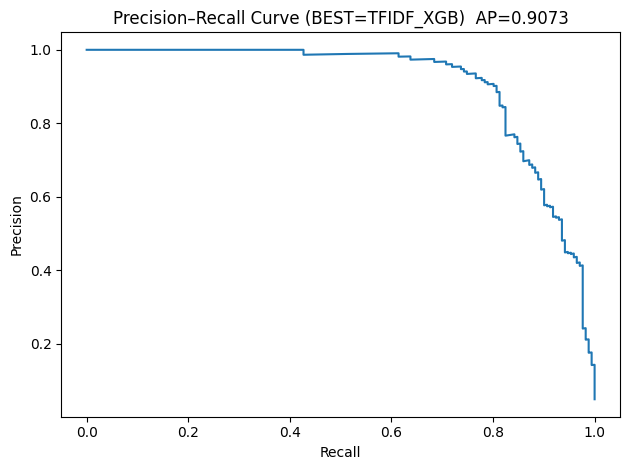

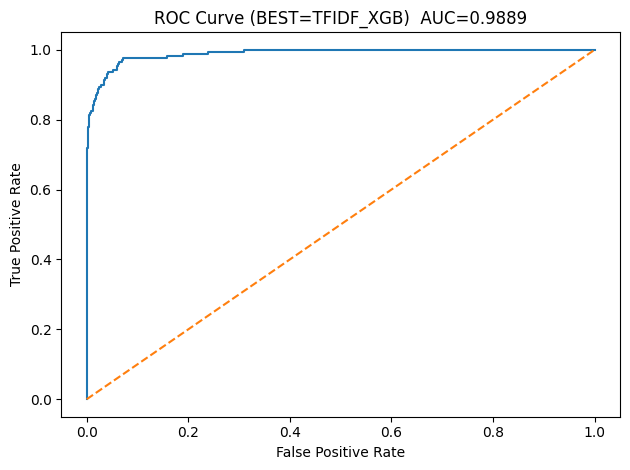

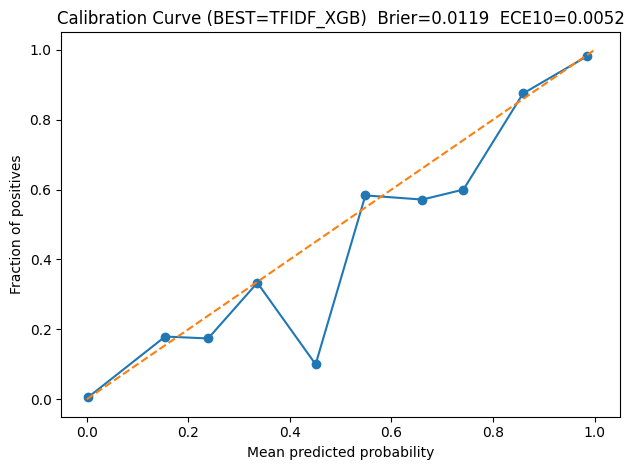

In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.mean()) * abs(acc - conf)
    return float(ece)

# pick y_prob according to best model
y_true = np.asarray(y_test).astype(int)

if best_model_name == "TFIDF_XGB":
    y_prob = proba_xgb_test
elif best_model_name == "TFIDF_LR":
    y_prob = proba_lr_test
elif best_model_name == "TFIDF_SVM":
    y_prob = proba_svm_test
elif best_model_name == "TFIDF_RF":
    y_prob = proba_rf_test
elif best_model_name == "Word2Vec_LR":
    y_prob = proba_w2v_test
elif best_model_name == "DistilBERT":
    y_prob = bert_prob_fake_test
else:
    # fallback to xgb
    y_prob = proba_xgb_test

pr_auc = average_precision_score(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)
brier = brier_score_loss(y_true, y_prob)
ece10 = expected_calibration_error(y_true, y_prob, n_bins=10)

metrics_payload = {
    "best_model_name": str(best_model_name),
    "pr_auc_average_precision": float(pr_auc),
    "roc_auc": float(roc_auc),
    "brier_score": float(brier),
    "ece_10bins": float(ece10),
}
with open(os.path.join(EVAL_DIR, "best_model_auc_calibration_metrics.json"), "w") as f:
    json.dump(metrics_payload, f, indent=2)

print(f"✔️ Deep evaluation saved in {EVAL_DIR}")
print(f"BEST={best_model_name} | PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f} | Brier={brier:.4f} | ECE10={ece10:.4f}")

# PR curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
pd.DataFrame({"precision": precision, "recall": recall}).to_csv(
    os.path.join(EVAL_DIR, "best_model_pr_curve.csv"), index=False
)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (BEST={best_model_name})  AP={pr_auc:.4f}")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "best_model_pr_curve.png"), dpi=200)
plt.show()

# ROC curve (appendix)
fpr, tpr, _ = roc_curve(y_true, y_prob)
pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(
    os.path.join(EVAL_DIR, "best_model_roc_curve.csv"), index=False
)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (BEST={best_model_name})  AUC={roc_auc:.4f}")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "best_model_roc_curve.png"), dpi=200)
plt.show()

# Calibration curve
frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
pd.DataFrame({"mean_predicted_prob": mean_pred, "fraction_of_positives": frac_pos}).to_csv(
    os.path.join(EVAL_DIR, "best_model_calibration_curve.csv"), index=False
)
plt.figure()
plt.plot(mean_pred, frac_pos, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title(f"Calibration Curve (BEST={best_model_name})  Brier={brier:.4f}  ECE10={ece10:.4f}")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "best_model_calibration_curve.png"), dpi=200)
plt.show()

### Save results

In [ ]:
# save comparison table
comparison.to_csv(os.path.join(EVAL_DIR, "model_comparison.csv"), index=True)

# save thresholds for reproducibility
thresholds_payload = {
    "best_t_lr_eval": float(best_t_lr),
    "best_t_svm_eval": float(best_t_svm),
    "best_t_rf_eval": float(best_t_rf),
    "best_t_xgb_eval": float(best_t_xgb),
    "best_t_w2v_eval": float(best_t_w2v),

    # XGB early-stopping result (for deploy reproducibility)
    "best_n_xgb_eval": int(best_n),
}

with open(os.path.join(EVAL_DIR, "best_thresholds_eval.json"), "w") as f:
    json.dump(thresholds_payload, f, indent=2)

# save best model artifact (evaluated)

if best_model_name == "TFIDF_XGB":
    joblib.dump(xgb, os.path.join(EVAL_DIR, "best_model_eval.joblib"))
elif best_model_name == "TFIDF_LR":
    joblib.dump(lr, os.path.join(EVAL_DIR, "best_model_eval.joblib"))
elif best_model_name == "TFIDF_SVM":
    joblib.dump(svm, os.path.join(EVAL_DIR, "best_model_eval.joblib"))
elif best_model_name == "TFIDF_RF":
    joblib.dump(rf, os.path.join(EVAL_DIR, "best_model_eval.joblib"))
elif best_model_name == "Word2Vec_LR":
    joblib.dump(lr_w2v, os.path.join(EVAL_DIR, "best_model_eval.joblib"))
elif best_model_name == "DistilBERT":
    trainer.save_model(os.path.join(EVAL_DIR, "best_bert_model_eval"))
else:
    print("⚠️ Unknown best model name — not saved automatically.")

print("✔️ Saved evaluation artifacts to:", EVAL_DIR)
print("✔️ Best model:", best_model_name)

✔️ Saved evaluation artifacts to: .\artifacts_eval
✔️ Best model: TFIDF_XGB


# **Deployment**

### Final Model Training with full data

From the evaluation table, the best overall model is TFIDF_XGB

In [ ]:
with open(os.path.join(EVAL_DIR, "best_thresholds_eval.json"), "r") as f:
    thr_eval = json.load(f)
best_t_xgb_deploy = float(thr_eval.get("best_t_xgb_eval", best_t_xgb))
print("✔️ Loaded best_t_xgb_eval for deploy:", best_t_xgb_deploy)
best_n = int(thr_eval["best_n_xgb_eval"])
print("✔️ Loaded best_n_xgb_eval for deploy:", best_n)


idx_trainval2 = np.concatenate([idx_train, idx_val])

tfidf_final = TfidfVectorizer(
    max_features=120_000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32
)

X_text_trainval = tfidf_final.fit_transform(df_clean.iloc[idx_trainval2][text_col_ml].astype(str))
X_trainval = hstack([X_text_trainval, X_structured_sp[idx_trainval2]]).tocsr()
y_trainval = df_clean.iloc[idx_trainval2]["fraudulent"].astype(int).values

# Retrain on TRAIN+VAL using best_n from early stopping (chosen on VAL)
# do not run early stopping here because VAL has been merged into training data.
xgb_final = XGBClassifier(
    n_estimators=best_n,
    max_depth=8,
    min_child_weight=2,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.05,
    reg_alpha=0.2,
    reg_lambda=2.0,

    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=SEED,
    n_jobs=-1,

    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    tree_method="hist",          # change to "gpu_hist" if GPU works
    max_bin=256
)

xgb_final.fit(X_trainval, y_trainval)
print("✔️ xgb_final trained on TRAIN+VAL")

# evaluate once on TEST using the VAL-tuned threshold (consistent rule)
X_text_test_final = tfidf_final.transform(df_clean.iloc[idx_test][text_col_ml].astype(str))
X_test_final = hstack([X_text_test_final, X_structured_sp[idx_test]]).tocsr()
y_test_final = df_clean.iloc[idx_test]["fraudulent"].astype(int).values

proba_test_final = xgb_final.predict_proba(X_test_final)[:, 1]
y_pred_test_final = (proba_test_final >= best_t_xgb_deploy).astype(int)

print("\n✔️ FINAL TEST (Deploy model)")
print("F1:", f1_score(y_test_final, y_pred_test_final, zero_division=0))
print("PR-AUC:", average_precision_score(y_test_final, proba_test_final))
print(classification_report(y_test_final, y_pred_test_final, digits=4))

✔️ Loaded best_t_xgb_eval for deploy: 0.46535353535353535
✔️ Loaded best_n_xgb_eval for deploy: 992
✔️ xgb_final trained on TRAIN+VAL

✔️ FINAL TEST (Deploy model)
F1: 0.8685015290519877
PR-AUC: 0.9310736802534434
              precision    recall  f1-score   support

           0     0.9913    0.9958    0.9935      3323
           1     0.9103    0.8304    0.8685       171

    accuracy                         0.9877      3494
   macro avg     0.9508    0.9131    0.9310      3494
weighted avg     0.9873    0.9877    0.9874      3494



In [ ]:
# for lime and demo
# 1. Load the artifacts you just saved
xgb_final = joblib.load(os.path.join(DEPLOY_DIR, "best_model.joblib"))
tfidf_final = joblib.load(os.path.join(DEPLOY_DIR, "tfidf.joblib"))

with open(os.path.join(DEPLOY_DIR, "best_thresholds.json"), "r") as f:
    thr = json.load(f)
    best_t = thr["best_t_xgb"]

# 2. Re-create the test features (X_test_final)
# This assumes df_clean, idx_test, and X_structured_sp are in memory
X_text_test = tfidf_final.transform(df_clean.iloc[idx_test][text_col_ml].astype(str))
X_test_final = hstack([X_text_test, X_structured_sp[idx_test]]).tocsr()

# 3. Generate the variables needed for the demo extract
proba_test_final = xgb_final.predict_proba(X_test_final)[:, 1]
y_pred_test_final = (proba_test_final >= best_t).astype(int)

# 4. extract the CSV
df_demo = df_clean.iloc[idx_test].copy()
df_demo['prediction_prob'] = proba_test_final
df_demo['predicted_label'] = y_pred_test_final

demo_path = os.path.join(DEPLOY_DIR, "final_test_demo_data.csv")
df_demo.to_csv(demo_path, index=False)

print(f"✔️ Demo data extracted successfully to: {demo_path}")

✔️ Demo data extracted successfully to: .\artifacts_deploy\final_test_demo_data.csv


In [58]:
# SAVE DEPLOY ARTIFACTS (Streamlit will load these)
joblib.dump(xgb_final, os.path.join(DEPLOY_DIR, "best_model.joblib"))
joblib.dump(tfidf_final, os.path.join(DEPLOY_DIR, "tfidf.joblib"))

# structured preprocessing artifacts (must match training)
joblib.dump(scaler, os.path.join(DEPLOY_DIR, "scaler.joblib"))
joblib.dump(ohe, os.path.join(DEPLOY_DIR, "ohe.joblib"))
joblib.dump(label_encoders, os.path.join(DEPLOY_DIR, "label_encoders.joblib"))
joblib.dump(X_structured.columns.tolist(), os.path.join(DEPLOY_DIR, "structured_columns.joblib"))
joblib.dump(feature_groups, os.path.join(DEPLOY_DIR, "feature_groups.joblib"))

# threshold for decision rule
with open(os.path.join(DEPLOY_DIR, "best_thresholds.json"), "w") as f:
    json.dump(
        {
            "best_t_xgb": float(best_t_xgb_deploy),
            "best_n_xgb": int(best_n)
        },
        f,
        indent=2
    )


In [59]:
# bundle deploy filenames for cleaner app loading

DEPLOY_BUNDLE = {
    "model": "best_model.joblib",
    "tfidf": "tfidf.joblib",
    "scaler": "scaler.joblib",
    "ohe": "ohe.joblib",
    "label_encoders": "label_encoders.joblib",
    "structured_columns": "structured_columns.joblib",
    "feature_groups": "feature_groups.joblib",
    "thresholds": "best_thresholds.json"
}

with open(os.path.join(DEPLOY_DIR, "deploy_bundle.json"), "w") as f:
    json.dump(DEPLOY_BUNDLE, f, indent=2)

print("✔️ Saved deploy_bundle.json")

for fn in [
    "scaler.joblib", "ohe.joblib", "label_encoders.joblib",
    "structured_columns.joblib", "feature_groups.joblib",
    "deploy_bundle.json"
]:
    assert os.path.exists(os.path.join(DEPLOY_DIR, fn)), f"Missing: {fn}"
print("✔️ All deploy files exist.")


✔️ Saved deploy_bundle.json
✔️ All deploy files exist.


## 8. Feature Importance Analysis

In [61]:
best_model_name = comparison.index[0]
print("\nBest overall model:", best_model_name)

tfidf_used = tfidf_final if "tfidf_final" in globals() else tfidf
tfidf_names = tfidf_used.get_feature_names_out()
structured_names = np.array(X_structured.columns.tolist())
all_feature_names = np.concatenate([tfidf_names, structured_names])

def show_top_features(importances, feature_names, top_n=30, title="Top Features"):
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False)

    display(imp_df.head(top_n))

    plt.figure(figsize=(8, 6))
    plot_df = imp_df.head(top_n).iloc[::-1]
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.savefig(
        os.path.join(FEAT_DIR, "01_xgb_top_features_gain.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    return imp_df



Best overall model: TFIDF_XGB



✅ Global Top Features for XGBoost (Gain):


,feature,importance
1368,achieve career goal,908.702148
77872,petroleum,550.681763
120004,has_company_profile,541.239807
104225,system service,433.907837
22124,corporate,411.445984
13437,candidate encourage,403.180084
20285,computer literate,391.046875
59585,leverage career,364.871887
57520,kuala lumpur,309.824219
84384,provide administrative,281.931152


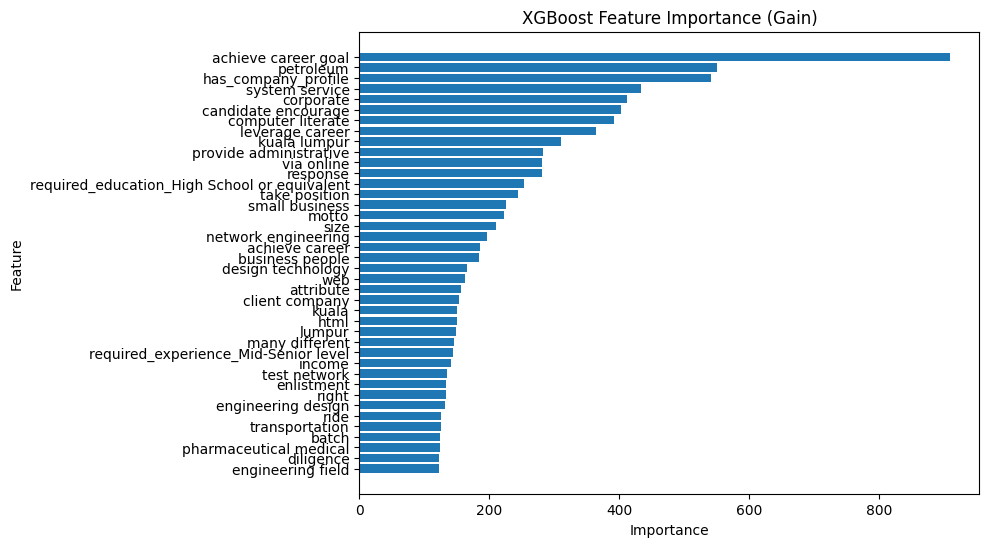


✔️ Group-level Importance (XGB):


,group,importance_score
0,Text (TF-IDF),29020.809203
1,Structured features,1258.920178



✔️ Top Variable Importance (COLUMN-level, grouped):


,variable,total_importance
0,has_company_profile,541.239807
1,required_education,298.017595
2,required_experience,150.521434
3,has_company_logo,65.930656
4,log_salary_avg,58.515442
5,employment_type,38.873350
6,log_salary_span,35.425835
7,has_salary,12.930676
8,telecommuting,11.754495
9,function,9.382440


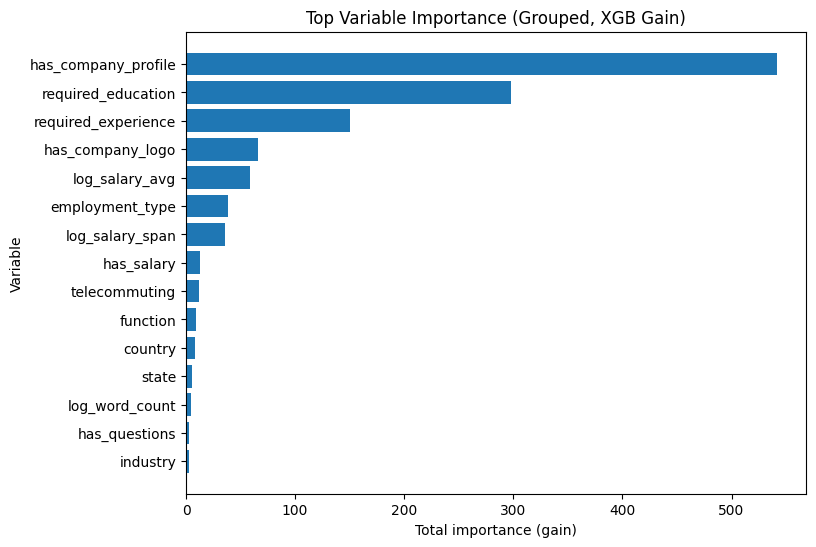

In [ ]:
# from the evaluation part, the best model is TFIDF_XGB
if best_model_name == "TFIDF_XGB":
    # use FINAL model if exists, else fallback to evaluated xgb
    if "xgb_final" in globals() and "tfidf_final" in globals():
      model_for_imp = xgb_final
      tfidf_used = tfidf_final
    else:
      model_for_imp = xgb
      tfidf_used = tfidf
      print("fallback to evaluated xgb/tfidf")

    booster = model_for_imp.get_booster()
    score = booster.get_score(importance_type="gain")

    importances = np.zeros(len(all_feature_names), dtype=float)
    for k, v in score.items():
        j = int(k[1:])
        if j < len(importances):
            importances[j] = v

    print("\n✅ Global Top Features for XGBoost (Gain):")
    imp_df = show_top_features(importances, all_feature_names, top_n=40,
                               title="XGBoost Feature Importance (Gain)")

    # Group-level: Text vs Structured
    tfidf_len = len(tfidf_names)
    text_gain = importances[:tfidf_len].sum()
    structured_gain = importances[tfidf_len:].sum()

    group_imp = pd.DataFrame({
        "group": ["Text (TF-IDF)", "Structured features"],
        "importance_score": [text_gain, structured_gain]
    }).sort_values("importance_score", ascending=False)

    print("\n✔️ Group-level Importance (XGB):")
    display(group_imp)

    # Column-level importance (variable-level, not one-hot level)
    structured_imp = pd.DataFrame({
        "feature": structured_names,
        "importance": importances[tfidf_len:]
    })

    low_card_cols = feature_groups["low_card_cols"]

    # map structured column names back to "original variable"
    # examples:
    # employment_type_Full-time  -> employment_type
    # department_Sales           -> department
    # city (label encoded)       -> city
    def base_var(colname: str):
        for prefix in low_card_cols:
            if colname.startswith(prefix + "_"):
                return prefix
        return colname  # already base (binary/numeric/high_card)

    structured_imp["base_variable"] = structured_imp["feature"].apply(base_var)

    var_level = structured_imp.groupby("base_variable")["importance"].sum().sort_values(ascending=False)
    var_level_df = var_level.reset_index().rename(columns={"base_variable": "variable", "importance": "total_importance"})

    print("\n✔️ Top Variable Importance (COLUMN-level, grouped):")
    display(var_level_df.head(20))

    plt.figure(figsize=(8, 6))
    plot_df = var_level_df.head(15).iloc[::-1]
    plt.barh(plot_df["variable"], plot_df["total_importance"])
    plt.title("Top Variable Importance (Grouped, XGB Gain)")
    plt.xlabel("Total importance (gain)")
    plt.ylabel("Variable")

    plt.savefig(
        os.path.join(FEAT_DIR, "02_xgb_structured_variable_importance_gain.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:
    print("\n⚠️ Feature importance block is designed for TFIDF_XGB best model.")

## 9. Explainable AI (XAI) — for TFIDF_XGB (Best Model)

### **LIME**

In [27]:
# rerun LIME CODE
# need to rerun def clean_text_for_ml, stop words, encoding
# Load the bundle configuration
with open(os.path.join(DEPLOY_DIR, "deploy_bundle.json"), "r") as f:
    bundle = json.load(f)

# Load the actual objects
xgb_final = joblib.load(os.path.join(DEPLOY_DIR, bundle["model"]))
tfidf_final = joblib.load(os.path.join(DEPLOY_DIR, bundle["tfidf"]))
struct_scaler = joblib.load(os.path.join(DEPLOY_DIR, bundle["scaler"]))
struct_cols = joblib.load(os.path.join(DEPLOY_DIR, bundle["structured_columns"]))

# First training model (before evaluation) - backup purpose only
xgb = joblib.load(os.path.join(EVAL_DIR, "best_model_eval.joblib"))
tfidf = joblib.load(os.path.join(EVAL_DIR, "tfidf.joblib"))

In [28]:
# Check which one was used
if "xgb_final" in globals():
    model_for_xai = xgb_final
    print("Using: xgb_final")
else:
    model_for_xai = xgb
    print("Using: xgb (fallback)")

booster = model_for_xai.get_booster()

# Feature names mapping
tfidf_used = tfidf_final if "tfidf_final" in globals() else tfidf
tfidf_names = tfidf_used.get_feature_names_out()

structured_names = np.array(X_structured.columns.tolist())
all_feature_names = np.concatenate([tfidf_names, structured_names])
tfidf_len = len(tfidf_names)

print("✔️ XAI model:", type(model_for_xai).__name__)
print("✔️ Total features:", len(all_feature_names), "| TF-IDF:", tfidf_len, "| Structured:", len(structured_names))

Using: xgb_final
✔️ XAI model: XGBClassifier
✔️ Total features: 121379 | TF-IDF: 120000 | Structured: 1379


LIME LOGIC

clean_text → TF-IDF → model
- display raw text
- clean internally to match training

In [29]:
# use df_test for lime
df_test = pd.read_csv(os.path.join(DEPLOY_DIR, "final_test_demo_data.csv"))

In [47]:
lime_model = model_for_xai

IDX_REAL = 0
IDX_FAKE = 1

explainer_lime = LimeTextExplainer(
    class_names=["Real", "Fake"],
    random_state=SEED
)

def lime_predict_proba(text_list, struct_row_vector_1d):
    # Clean the raw text before passing to TF-IDF
    cleaned_text_list = [clean_text_for_ml(t) for t in text_list]
    
    X_text_new = tfidf_used.transform(cleaned_text_list)
    X_struct_rep = np.repeat(
        struct_row_vector_1d.reshape(1, -1),
        repeats=len(text_list),
        axis=0
    )
    X_new = hstack([X_text_new, csr_matrix(X_struct_rep)]).tocsr()
    return lime_model.predict_proba(X_new)

structured_cols = X_structured.columns.tolist()
X_structured_aligned = X_structured.reindex(columns=structured_cols, fill_value=0)

# 1) if want to test with borderline
scores = []
for i in range(len(df_test)):
    p = lime_predict_proba(
        [df_test["text"].iloc[i]], #change RAW text
        X_structured_aligned.iloc[i].values.astype(float)
    )[0][1]  # Fake prob
    scores.append((i, p))

# Sort by closeness to 0.5 (most uncertain predictions)
borderline = sorted(scores, key=lambda x: abs(x[1] - 0.5))[:10]

for i, p in borderline:
    print(f"row_index = {i}, fake_probability = {p:.4f}")

print(len(borderline))

# borderline(i,p), change i only (0-9) 
sample_row = int(borderline[0][0])

# 2) if just want to pick a sample row
# sample_row = 20

sample_text = df_test['text'].iloc[sample_row]  
true_label = int(df_test["fraudulent"].iloc[sample_row])

original_index = df_test.index[sample_row]
struct_vec = X_structured_aligned.loc[original_index].values.astype(float)

print("True label:", true_label)
print("Text preview:", sample_text[:200])

cleaned_sample = clean_text_for_ml(sample_text)
proba = lime_model.predict_proba(
    hstack([
        tfidf_used.transform([cleaned_sample]),
        csr_matrix(struct_vec.reshape(1, -1))
    ]).tocsr()
)[0]

pred = int(np.argmax(proba))  # 0=Real, 1=Fake

exp = explainer_lime.explain_instance(
    sample_text,
    classifier_fn=lambda txts: lime_predict_proba(txts, struct_vec),
    num_features=12,
    labels=[IDX_REAL, IDX_FAKE] # Ensure both are available
)

# 3. ALWAYS show the HTML for the FAKE label (Index 1)
# This ensures Orange = Fake and Blue = Real every single time, matching the logic you used in your app.
lime_html = exp.as_html(labels=[IDX_FAKE])

lime_path = os.path.join(XAI_DIR, "lime_text_explanation.html")
with open(lime_path, 'w', encoding='utf-8') as f:
    f.write(lime_html)

print("✔️ LIME explanation saved to:", lime_path)

exp.show_in_notebook(labels=[IDX_FAKE])

row_index = 1043, fake_probability = 0.4981
row_index = 705, fake_probability = 0.4877
row_index = 3126, fake_probability = 0.4875
row_index = 2953, fake_probability = 0.5163
row_index = 889, fake_probability = 0.5179
row_index = 2773, fake_probability = 0.4780
row_index = 371, fake_probability = 0.4700
row_index = 3169, fake_probability = 0.5306
row_index = 2685, fake_probability = 0.5326
row_index = 32, fake_probability = 0.4603
10
True label: 0
Text preview: Finance Assistant. AU, NSW, Sydney. finance. Our Company has a new position available for an experienced Finance Assistant wishing to join a successful stable organisation.Elements of these roles may 
✔️ LIME explanation saved to: .\xai_outputs\lime_text_explanation.html


In [48]:
# The score represents how well the linear model fits your actual model locally
print(f"LIME Fidelity Score (R^2): {exp.score:.4f}")

# If this is below 0.10, the "Fake/Real" labels for words are likely inaccurate.
if exp.score < 0.30:
    print("⚠️ Warning: LIME is struggling to approximate your model here.")

LIME Fidelity Score (R^2): 0.6552


LIME fidelity measures how well a simple linear surrogate matches the model locally. For tree-based hybrid models like TF-IDF + XGBoost, the decision function can be highly non-linear and interaction-driven, so the linear approximation can be less accurate on some instances, especially ambiguous or borderline samples.

In [49]:
# Use the class names you defined in your explainer
class_names = ["Real", "Fake"] 

# Get the top features for the predicted class
exp_list = exp.as_list(label=pred)

print(f"Prediction for this sample: {class_names[pred]}")
print(f"{'Word':<15} | {'Effect'}")
print("-" * 30)

for word, weight in exp_list:
    # If weight is positive, it pushes TOWARD the predicted class
    # If weight is negative, it pushes AWAY from the predicted class
    if weight > 0:
        direction = f"Pushing toward {class_names[pred]}"
    else:
        # Get the 'other' class index (if pred is 1, other is 0; if pred is 0, other is 1)
        other_class = class_names[1 - pred]
        direction = f"Pushing toward {other_class}"
        
    print(f"{word:<15} | {direction} (Weight: {weight:+.4f})")

Prediction for this sample: Real
Word            | Effect
------------------------------
new             | Pushing toward Real (Weight: +0.2900)
Assistant       | Pushing toward Fake (Weight: -0.2131)
management      | Pushing toward Real (Weight: +0.1023)
Company         | Pushing toward Fake (Weight: -0.0756)
Excel           | Pushing toward Fake (Weight: -0.0649)
successful      | Pushing toward Real (Weight: +0.0553)
experienced     | Pushing toward Real (Weight: +0.0504)
position        | Pushing toward Real (Weight: +0.0460)
background      | Pushing toward Real (Weight: +0.0460)
areas           | Pushing toward Real (Weight: +0.0297)
Experience      | Pushing toward Real (Weight: +0.0245)
shared          | Pushing toward Real (Weight: +0.0219)
